In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("system_logins.csv")
df.head()

,timestamp,user_id,ip_address,country,success,os
0,2026-04-21 19:39:00,user_4,7.140.125.58,UK,0,Windows
1,2026-04-21 22:11:00,user_18,23.216.16.8,USA,1,Linux
2,2026-04-20 15:52:00,user_17,155.13.101.184,Kenya,1,iOS
3,2026-04-21 04:38:00,user_8,115.142.3.195,UK,1,Android
4,2026-04-20 23:13:00,user_9,40.110.172.27,USA,0,Android


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   timestamp   200 non-null    object
 1   user_id     200 non-null    object
 2   ip_address  200 non-null    object
 3   country     200 non-null    object
 4   success     200 non-null    int64 
 5   os          200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB


In [4]:
df.isnull().sum()

timestamp     0
user_id       0
ip_address    0
country       0
success       0
os            0
dtype: int64

In [9]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [11]:
df["hour"] = df["timestamp"].dt.hour
df.head()

,timestamp,user_id,ip_address,country,success,os,hour
0,2026-04-21 19:39:00,user_4,7.140.125.58,UK,0,Windows,19.0
1,2026-04-21 22:11:00,user_18,23.216.16.8,USA,1,Linux,22.0
2,2026-04-20 15:52:00,user_17,155.13.101.184,Kenya,1,iOS,15.0
3,2026-04-21 04:38:00,user_8,115.142.3.195,UK,1,Android,4.0
4,2026-04-20 23:13:00,user_9,40.110.172.27,USA,0,Android,23.0


In [14]:
login_counts = df['success'].value_counts()
print(login_counts)

1    110
0     90
Name: success, dtype: int64


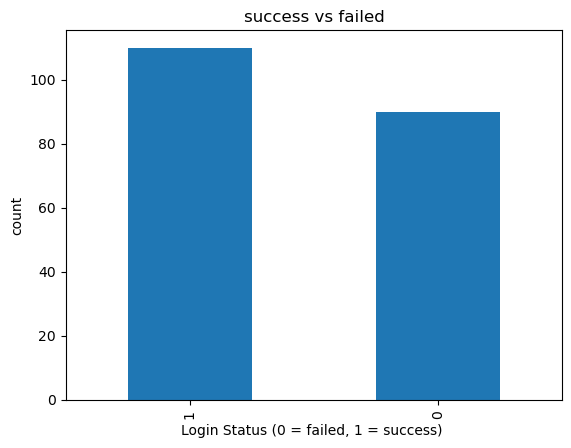

In [16]:
login_counts.plot(kind = "bar")
plt.title("success vs failed")
plt.xlabel("Login Status (0 = failed, 1 = success) ")
plt.ylabel("count")
plt.show()

In [17]:
failed_logins = df[df['success'] == 0]

top_users = failed_logins['user_id'].value_counts().head(5)
print(top_users)

user_15    9
user_16    9
user_7     7
user_10    6
user_1     6
Name: user_id, dtype: int64


In [18]:
ip_per_country = df.groupby('country')['ip_address'].nunique()
print(ip_per_country)

country
Germany    25
India      37
Kenya      39
UK         36
USA        31
Uganda     32
Name: ip_address, dtype: int64


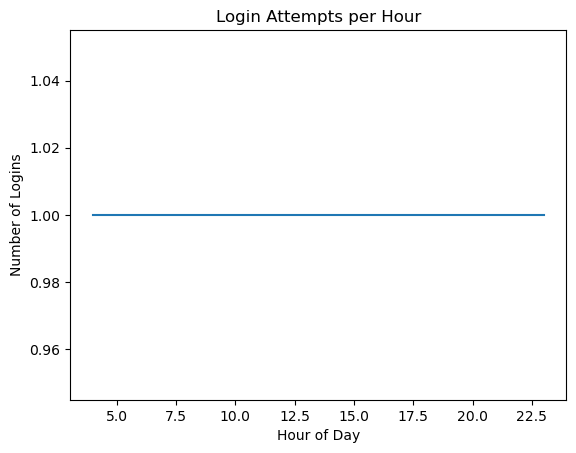

In [19]:
hourly_logins = df.groupby('hour').size()

hourly_logins.plot(kind='line')
plt.title("Login Attempts per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Logins")
plt.show()

In [20]:
failed_by_hour = df[df['success'] == 0].groupby('hour').size()

peak_hour = failed_by_hour.idxmax()
print("Hour with highest failed logins:", peak_hour)

Hour with highest failed logins: 19.0


If failed logins spike at unusual hours (e.g., midnight–4 AM), it may indicate brute-force attacks or unauthorized access attempts.

In [21]:

df = df.sort_values(by=['user_id', 'timestamp'])

df['prev_time'] = df.groupby('user_id')['timestamp'].shift(1)
df['prev_success'] = df.groupby('user_id')['success'].shift(1)

df['time_diff'] = (df['timestamp'] - df['prev_time']).dt.total_seconds() / 60

suspicious = df[
    (df['prev_success'] == 0) &
    (df['success'] == 1) &
    (df['time_diff'] <= 5)
]

failed_counts = df[df['success'] == 0]['user_id'].value_counts()

high_fail_users = failed_counts[failed_counts > 10].index

flagged_users = suspicious[suspicious['user_id'].isin(high_fail_users)]['user_id'].unique()

print("Suspicious users:", flagged_users)

Suspicious users: []


### Findings:
1. The dataset shows both successful and failed login attempts, with a noticeable number of failures.
2. A few users have significantly higher failed login attempts, indicating possible targeted attacks.
3. Certain hours of the day show spikes in login activity, especially failed attempts.
4. Some users had multiple failed attempts followed by a quick success, which is suspicious.
5. Multiple IP addresses across countries suggest possible distributed access patterns.

### Recommendations:
1. Implement account lockout policies after repeated failed login attempts.
2. Monitor and alert on unusual login times and rapid fail-success patterns.